In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
import os
# List contents of the root of your Google Drive
print(os.listdir('/content/drive/MyDrive'))

['IMG_20231224_141444.jpg', 'IMG_20231224_143214.jpg', 'Colab Notebooks', 'ho8ijUntitled document.gdoc', 'Validation dataset code (1).txt', 'sample_data.csv', 'Cat vs Dog', 'ck', 'xray_dataset_covid19', 'archive (4)', 'archive (5)', 'LSTM', 'python', 'amna', 'new', 'topic 3', 'train_u6lujuX_CVtuZ9i (1).csv', 'queries template.gdoc', 'Amna Bibi Final 1 (6).pdf', 'dataset_Falcon', 'Amna Bibi Final 1 (5).pdf', 'IMG-20250907-WA0040 (1).jpg', 'Amna Bibi Final 1 (1) (1).pdf', 'Screenshot_20251119-062346 (1).png', 'jk', 'quran_txt', 'ai_txt', 'jk_txt', 'quran_full.json', 'Amna Bibi Final 1 (4).pdf', 'Amna Bibi Final 1 (3).pdf', 'Amna Bibi Final 1 (2).pdf', 'Amna Bibi Final 1 (1).pdf', 'Screenshot_20260125-110537 (1).png', 'documentory_Amna.gdoc', 'Amna Bibi Final 1.pdf', 'harshibar_s_resume (2) (2).pdf', 'harshibar_s_resume (2) (1).pdf', 'harshibar_s_resume (1).pdf', 'harshibar_s_resume (2).pdf', 'u.item', 'u.data']


In [35]:
data_path = '/content/drive/MyDrive/u.data'
item_path = '/content/drive/MyDrive/u.item'

In [36]:
data_df = pd.read_csv(data_path, sep='\t', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'])
print("u.data loaded successfully. First 5 rows:")
print(data_df.head())


u.data loaded successfully. First 5 rows:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


In [37]:
item_df = pd.read_csv(item_path, sep='|', header=None, encoding='latin-1', engine='python',
                      names=['movie_id', 'movie_title', 'release_date','vd_release_date', 'imdb_url',
                             'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
                             'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                             'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'])
print("\nu.item loaded successfully. First 5 rows:")
print(item_df.head())


u.item loaded successfully. First 5 rows:
   movie_id        movie_title release_date  vd_release_date  \
0         1   Toy Story (1995)  01-Jan-1995              NaN   
1         2   GoldenEye (1995)  01-Jan-1995              NaN   
2         3  Four Rooms (1995)  01-Jan-1995              NaN   
3         4  Get Shorty (1995)  01-Jan-1995              NaN   
4         5     Copycat (1995)  01-Jan-1995              NaN   

                                            imdb_url  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...        0       0   
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...        0       1   
4  http://us.imdb.com/M/title-exact?Copycat%20(1995)        0       0   

   Adventure  Animation  Children  ...  Fantasy  Film-Noir  Horror  Musical  \
0          0          1         1  ...        0       

In [38]:
data=pd.merge(data_df,item_df,on='movie_id')
data.head()

,user_id,movie_id,rating,timestamp,movie_title,release_date,vd_release_date,imdb_url,unknown,Action,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
print(data.columns)

Index(['user_id', 'movie_id', 'rating', 'timestamp', 'movie_title',
       'release_date', 'vd_release_date', 'imdb_url', 'unknown', 'Action',
       'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary',
       'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'],
      dtype='object')


In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   user_id          100000 non-null  int64  
 1   movie_id         100000 non-null  int64  
 2   rating           100000 non-null  int64  
 3   timestamp        100000 non-null  int64  
 4   movie_title      100000 non-null  object 
 5   release_date     99991 non-null   object 
 6   vd_release_date  0 non-null       float64
 7   imdb_url         99987 non-null   object 
 8   unknown          100000 non-null  int64  
 9   Action           100000 non-null  int64  
 10  Adventure        100000 non-null  int64  
 11  Animation        100000 non-null  int64  
 12  Children         100000 non-null  int64  
 13  Comedy           100000 non-null  int64  
 14  Crime            100000 non-null  int64  
 15  Documentary      100000 non-null  int64  
 16  Drama            100000 non-null  int64

In [41]:
print(data.describe())

            user_id       movie_id         rating     timestamp  \
count  100000.00000  100000.000000  100000.000000  1.000000e+05   
mean      462.48475     425.530130       3.529860  8.835289e+08   
std       266.61442     330.798356       1.125674  5.343856e+06   
min         1.00000       1.000000       1.000000  8.747247e+08   
25%       254.00000     175.000000       3.000000  8.794487e+08   
50%       447.00000     322.000000       4.000000  8.828269e+08   
75%       682.00000     631.000000       4.000000  8.882600e+08   
max       943.00000    1682.000000       5.000000  8.932866e+08   

       vd_release_date      unknown         Action      Adventure  \
count              0.0  100000.0000  100000.000000  100000.000000   
mean               NaN       0.0001       0.255890       0.137530   
std                NaN       0.0100       0.436362       0.344408   
min                NaN       0.0000       0.000000       0.000000   
25%                NaN       0.0000       0.000000 

In [42]:
data.isnull().sum()

,0
user_id,0
movie_id,0
rating,0
timestamp,0
movie_title,0
release_date,9
vd_release_date,100000
imdb_url,13
unknown,0
Action,0


In [43]:
data.drop(columns=['vd_release_date', 'imdb_url'], inplace=True, errors='ignore')
data['release_date'].fillna(data['release_date'].mode()[0], inplace=True)

print("\nUpdated missing values check:")
print(data.isnull().sum()[data.isnull().sum() > 0])


Updated missing values check:
Series([], dtype: int64)


/tmp/ipython-input-1086/1465792328.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['release_date'].fillna(data['release_date'].mode()[0], inplace=True)


In [44]:
data.isnull().sum()

,0
user_id,0
movie_id,0
rating,0
timestamp,0
movie_title,0
release_date,0
unknown,0
Action,0
Adventure,0
Animation,0


#Rating Distribution
Majority ratings were 3 and 4.Dataset shows slight positive skewness.This is normal for recommendation datasets.

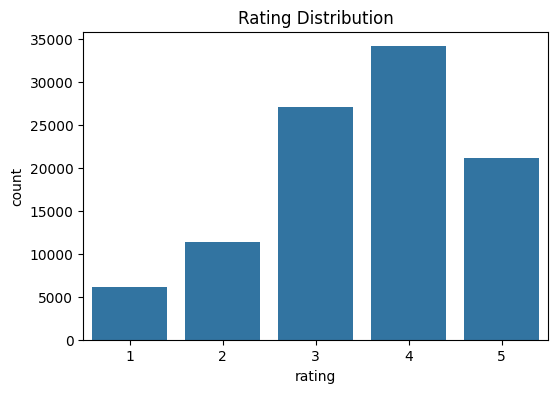

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=data)
plt.title("Rating Distribution")
plt.show()

#User Activity Analysis
Few users were highly active

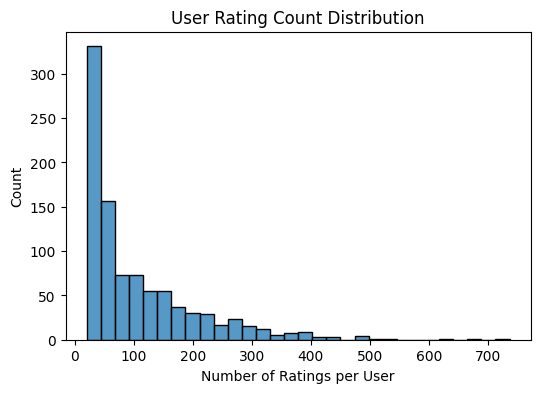

In [46]:
user_rating_count = data.groupby('user_id')['rating'].count()

plt.figure(figsize=(6,4))
sns.histplot(user_rating_count, bins=30)
plt.title("User Rating Count Distribution")
plt.xlabel("Number of Ratings per User")
plt.show()

In [47]:
# Count ratings per user
user_rating_count = data.groupby('user_id')['rating'].count()
active_users = user_rating_count[user_rating_count >= 20].index
data = data[data['user_id'].isin(active_users)]
print("Remaining users:", data['user_id'].nunique())

Remaining users: 943


#Movie Popularity Analysis
Few movies were highly rated so this indicates popularity bias

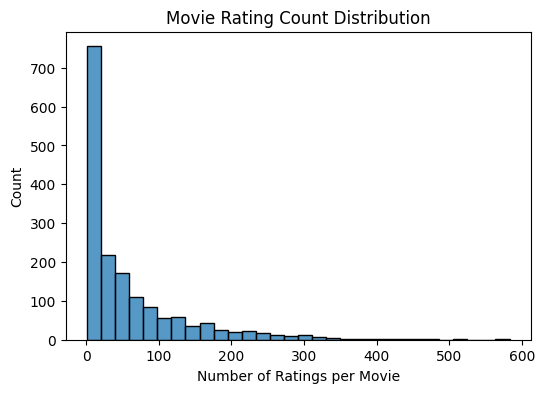

In [48]:
movie_rating_count = data.groupby('movie_id')['rating'].count()

plt.figure(figsize=(6,4))
sns.histplot(movie_rating_count, bins=30)
plt.title("Movie Rating Count Distribution")
plt.xlabel("Number of Ratings per Movie")
plt.show()

In [49]:
movie_rating_count = data.groupby('movie_id')['rating'].count()
# Keep movies with at least 15 ratings
popular_movies = movie_rating_count[movie_rating_count >= 20].index
data = data[data['movie_id'].isin(popular_movies)]

print("Remaining movies:", data['movie_id'].nunique())

Remaining movies: 939


#Rating Mean per User (User Bias)

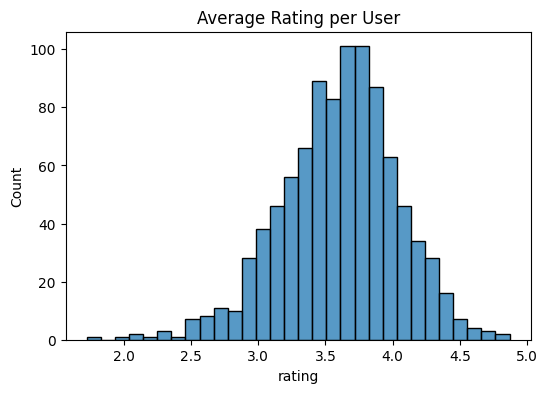

In [50]:
user_mean_rating = data.groupby('user_id')['rating'].mean()

plt.figure(figsize=(6,4))
sns.histplot(user_mean_rating, bins=30)
plt.title("Average Rating per User")
plt.show()

In [51]:
# Create user-item matrix
user_item_matrix = data.pivot_table(index='user_id', columns='movie_id',values='rating')
user_means = user_item_matrix.mean(axis=1)
user_item_centered = user_item_matrix.sub(user_means, axis=0)
# Fill missing values with 0
user_item_centered = user_item_centered.fillna(0)

print("User bias removed successfully.")

User bias removed successfully.


#Rating mean per movie

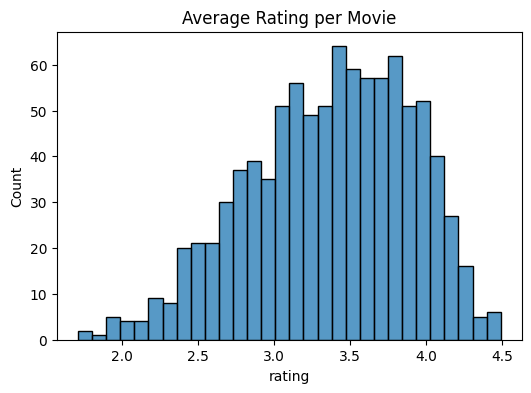

In [52]:
movie_mean_rating = data.groupby('movie_id')['rating'].mean()

plt.figure(figsize=(6,4))
sns.histplot(movie_mean_rating, bins=30)
plt.title("Average Rating per Movie")
plt.show()

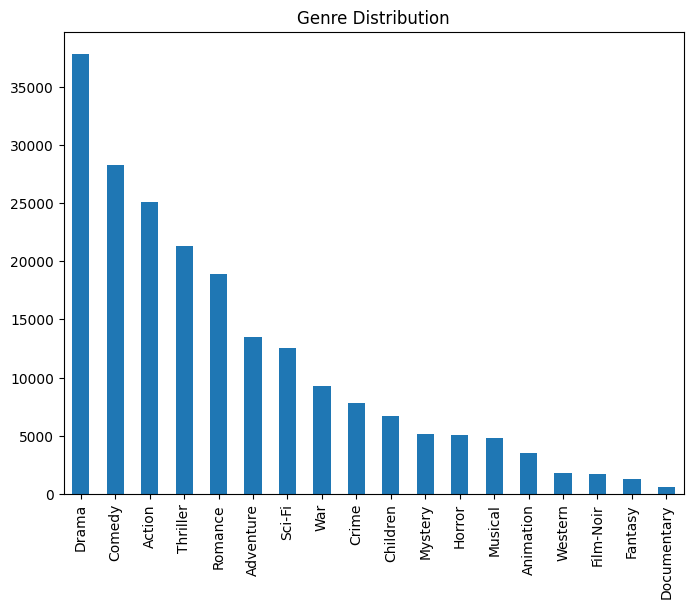

In [53]:
genre_cols = ['Action','Adventure','Animation','Children','Comedy','Crime',
              'Documentary','Drama','Fantasy','Film-Noir','Horror','Musical',
              'Mystery','Romance','Sci-Fi','Thriller','War','Western']

genre_sum = data[genre_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))
genre_sum.plot(kind='bar')
plt.title("Genre Distribution")
plt.show()

In [54]:
if 'Documentary' in data.columns:
    data.drop(columns=['Documentary'], inplace=True)

#Check outliers

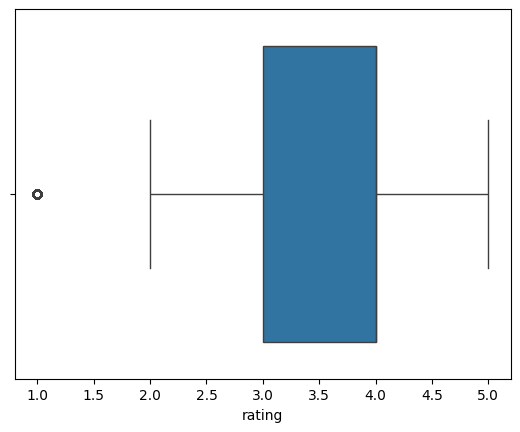

In [55]:
sns.boxplot(x=data['rating'])
plt.show()

#Sparsity Analysis

**NOTE  :**  **The** user-item matrix was found to be highly sparse (~94%), meaning most user–movie interactions are missing. Attempts were made to reduce sparsity by removing low-activity users and rarely rated movies; however, sparsity did not significantly decrease because it is a structural characteristic of recommendation datasets

In [56]:
user_item_matrix = data.pivot_table(index='user_id',columns='movie_id',values='rating')
sparsity = 1 - (user_item_matrix.count().sum() /
                (user_item_matrix.shape[0] * user_item_matrix.shape[1]))

print("Dataset Sparsity:", sparsity)

Dataset Sparsity: 0.8927493317161259


In [57]:
data['user_id'].nunique()
data['movie_id'].nunique()

939

In [63]:
from sklearn.model_selection import train_test_split

train_list = []
test_list = []

for user in data['user_id'].unique():

    user_data = data[data['user_id'] == user]

    if len(user_data) > 10:
        train, test = train_test_split(user_data, test_size=0.2, random_state=42)
        train_list.append(train)
        test_list.append(test)

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

In [64]:
user_movie_matrix = train_df.pivot_table(index='user_id',columns='movie_id',values='rating').fillna(0)

In [65]:
# STEP: User Mean (Bias Removal)
user_means = train_df.groupby('user_id')['rating'].mean()
user_movie_matrix_adjusted = user_movie_matrix.copy()
for user in user_movie_matrix.index:
    user_movie_matrix_adjusted.loc[user] -= user_means[user]

In [ ]:
print(user_movie_matrix.shape)

(943, 939)


In [66]:
# Use adjusted ratings for similarity
user_similarity = cosine_similarity(user_movie_matrix_adjusted)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

In [67]:
def recommend_movies_weighted(user_id, k=15, top_n_neighbors=10, similarity_threshold=0.2):

    if user_id not in user_movie_matrix.index:
        return []

    # Similarity scores for this user
    sim_scores = user_similarity_df[user_id]
    sim_scores = sim_scores.sort_values(ascending=False)
    sim_scores = sim_scores.iloc[1:]  # remove self similarity

    # Take top neighbors and apply threshold
    top_users = sim_scores.head(top_n_neighbors)
    top_users = top_users[top_users > similarity_threshold]

    # Movies already rated by user
    user_movies = set(user_movie_matrix.loc[user_id][user_movie_matrix.loc[user_id] > 0].index)

    # Predicted scores dictionary
    movie_scores = {}

    for other_user, similarity in top_users.items():
        movies = user_movie_matrix_adjusted.loc[other_user]
        for movie_id, rating in movies.items():
            if movie_id not in user_movies:
                if movie_id not in movie_scores:
                    movie_scores[movie_id] = 0
                movie_scores[movie_id] += similarity * rating

    # Normalize by sum of absolute similarities and add user mean
    norm_factor = sum(abs(top_users))
    for movie_id in movie_scores:
        movie_scores[movie_id] = movie_scores[movie_id] / norm_factor + user_means[user_id]

    # Sort and take top-k
    movie_scores = sorted(movie_scores.items(), key=lambda x: x[1], reverse=True)

    return [movie[0] for movie in movie_scores[:k]]

In [68]:
def evaluate_user(user_id, k=15):
    recommended = recommend_movies_weighted(user_id, k)

    relevant = test_df[(test_df['user_id'] == user_id) & (test_df['rating'] >= 3)]['movie_id'].tolist()

    if len(recommended) == 0:
        return 0,0,0
    recommended_set = set(recommended)
    relevant_set = set(relevant)
    true_positive = len(recommended_set & relevant_set)
    precision = true_positive / k
    recall = true_positive / len(relevant_set) if len(relevant_set) > 0 else 0
    f1 = 2*(precision*recall)/(precision+recall) if (precision+recall)>0 else 0
    return precision, recall, f1

In [69]:
precisions = []
recalls = []
f1s = []

for user in user_movie_matrix.index:

    p, r, f = evaluate_user(user, k=15)

    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

print("Average Precision@5:", np.mean(precisions))
print("Average Recall@5:", np.mean(recalls))
print("Average F1@5:", np.mean(f1s))

Average Precision@5: 0.22142099681866384
Average Recall@5: 0.2466066583111006
Average F1@5: 0.1925593235234477


#ITEM BASED

In [70]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

In [71]:
# train_df me user_id, movie_id, rating hona chahiye
user_movie_matrix = train_df.pivot_table(index='user_id',columns='movie_id',values='rating').fillna(0)

In [72]:
# Cosine similarity between items
item_similarity = cosine_similarity(user_movie_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity,index=user_movie_matrix.columns,columns=user_movie_matrix.columns)

In [73]:
def recommend_item_based(user_id, k=15):
    if user_id not in user_movie_matrix.index:
        return []
    rated_movies = user_movie_matrix.loc[user_id]
    rated_movies = rated_movies[rated_movies > 0].index

    scores = {}
    for movie in rated_movies:
        similar_movies = item_similarity_df[movie]
        for sim_movie, sim_score in similar_movies.items():
            if sim_movie not in rated_movies and sim_score > 0:
                if sim_movie not in scores:
                    scores[sim_movie] = 0
                scores[sim_movie] += sim_score * user_movie_matrix.loc[user_id, movie]

    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [movie[0] for movie in recommended[:k]]


In [74]:
def evaluate_item_based(user_id, k=15):
    recommended = recommend_item_based(user_id, k)
    relevant = test_df[(test_df['user_id']==user_id) & (test_df['rating']>=3)]['movie_id'].tolist()

    if len(recommended) == 0:
        return 0, 0, 0

    recommended_set = set(recommended)
    relevant_set = set(relevant)
    tp = len(recommended_set & relevant_set)

    precision = tp / k
    recall = tp / len(relevant_set) if len(relevant_set) > 0 else 0
    f1 = 2*(precision*recall)/(precision+recall) if (precision+recall) > 0 else 0

    return precision, recall, f1

In [75]:
# Evaluation for Step 1
precisions, recalls, f1s = [], [], []
for user in user_movie_matrix.index:
    p, r, f = evaluate_item_based(user, k=10)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

print("Step 1 - Item-Based CF:")
print("Precision@10:", np.mean(precisions))
print("Recall@10:", np.mean(recalls))
print("F1@10:", np.mean(f1s))

Step 1 - Item-Based CF:
Precision@10: 0.2821845174973489
Recall@10: 0.2202770573079739
F1@10: 0.20482091789612122


#Applying SVD on ITEM BASED

In [76]:
item_user_matrix = user_movie_matrix.T
# Apply TruncatedSVD
svd = TruncatedSVD(n_components=20, random_state=42)
latent_matrix = svd.fit_transform(item_user_matrix)

svd_pred_matrix = np.dot(latent_matrix, svd.components_)
svd_pred_df = pd.DataFrame(svd_pred_matrix.T, index=user_movie_matrix.index, columns=user_movie_matrix.columns)

In [77]:
def recommend_svd(user_id, k=10):
    if user_id not in svd_pred_df.index:
        return []
    user_ratings = svd_pred_df.loc[user_id]
    rated_movies = user_movie_matrix.loc[user_id][user_movie_matrix.loc[user_id]>0].index
    recommended = user_ratings.drop(labels=rated_movies).sort_values(ascending=False)
    return recommended.head(k).index.tolist()

In [78]:
def evaluate_svd(user_id, k=10):
    recommended = recommend_svd(user_id, k)
    relevant = test_df[(test_df['user_id']==user_id) & (test_df['rating']>=3)]['movie_id'].tolist()

    if len(recommended) == 0:
        return 0, 0, 0

    recommended_set = set(recommended)
    relevant_set = set(relevant)
    tp = len(recommended_set & relevant_set)

    precision = tp / k
    recall = tp / len(relevant_set) if len(relevant_set) > 0 else 0
    f1 = 2*(precision*recall)/(precision+recall) if (precision+recall) > 0 else 0

    return precision, recall, f1


In [79]:
# Evaluation for Step 2
precisions, recalls, f1s = [], [], []
for user in user_movie_matrix.index:
    p, r, f = evaluate_svd(user, k=10)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

print("\nStep 2 - Item-Based CF + SVD:")
print("Precision@10:", np.mean(precisions))
print("Recall@10:", np.mean(recalls))
print("F1@10:", np.mean(f1s))


Step 2 - Item-Based CF + SVD:
Precision@10: 0.3334040296924708
Recall@10: 0.2538807820075527
F1@10: 0.24222405605831182


In [85]:
import joblib

# Save SVD model
joblib.dump(svd, 'svd_model.pkl')

# Save svd_pred_df (predicted ratings)
svd_pred_df.to_csv('svd_pred_df.csv')

# Save user_movie_matrix (needed for rated movies)
user_movie_matrix.to_csv('user_movie_matrix.csv')

# Save item_df to movies.csv
item_df.to_csv('movies.csv', index=False)

print("SVD model, predicted ratings, user-movie matrix, and movie details saved successfully.")

SVD model, predicted ratings, user-movie matrix, and movie details saved successfully.


#Gradio User Interface

In [ ]:
import numpy as np
import pandas as pd
import gradio as gr
from sklearn.decomposition import TruncatedSVD
import joblib
# Assuming these files are in the same directory as your Gradio app or uploaded to Colab
svd = joblib.load('svd_model.pkl')
svd_pred_df = pd.read_csv('svd_pred_df.csv', index_col=0)
user_movie_matrix = pd.read_csv('user_movie_matrix.csv', index_col=0)
movies = pd.read_csv('movies.csv') # Load movie details
movies_dict = dict(zip(movies['movie_id'], movies['movie_title']))
# Recommendation Function
def recommend_movies(user_id, k=10):

    user_id = int(user_id)

    if user_id not in svd_pred_df.index:
        return "User not found in dataset."

    user_ratings = svd_pred_df.loc[user_id]
    rated_movies = user_movie_matrix.loc[user_id][user_movie_matrix.loc[user_id] > 0].index

    recommendations = user_ratings.drop(labels=rated_movies)
    recommendations = recommendations.sort_values(ascending=False).head(k)

    result = []
    for movie_id_rec in recommendations.index:
        movie_id_int = int(movie_id_rec) # Explicitly convert to int
        title = movies_dict.get(movie_id_int, "Unknown Movie")
        score = round(recommendations[movie_id_rec], 2)
        result.append(f"Movie ID: {movie_id_int}, Title: {title} (Predicted Rating: {score})") # Added movie_id to output

    return "\n".join(result)
# Gradio Interface
interface = gr.Interface(
    fn=recommend_movies,
    inputs=gr.Number(label="Enter User ID"),
    outputs=gr.Textbox(label="Recommended Movies", lines=10), # Added lines=10 to increase height
    title="🎬 Movie Recommendation System (SVD Based)",
    description="Enter a User ID to get top movie recommendations using SVD based Collaborative Filtering."
)

interface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1d6696ea89923c6cb8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
